findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Ari

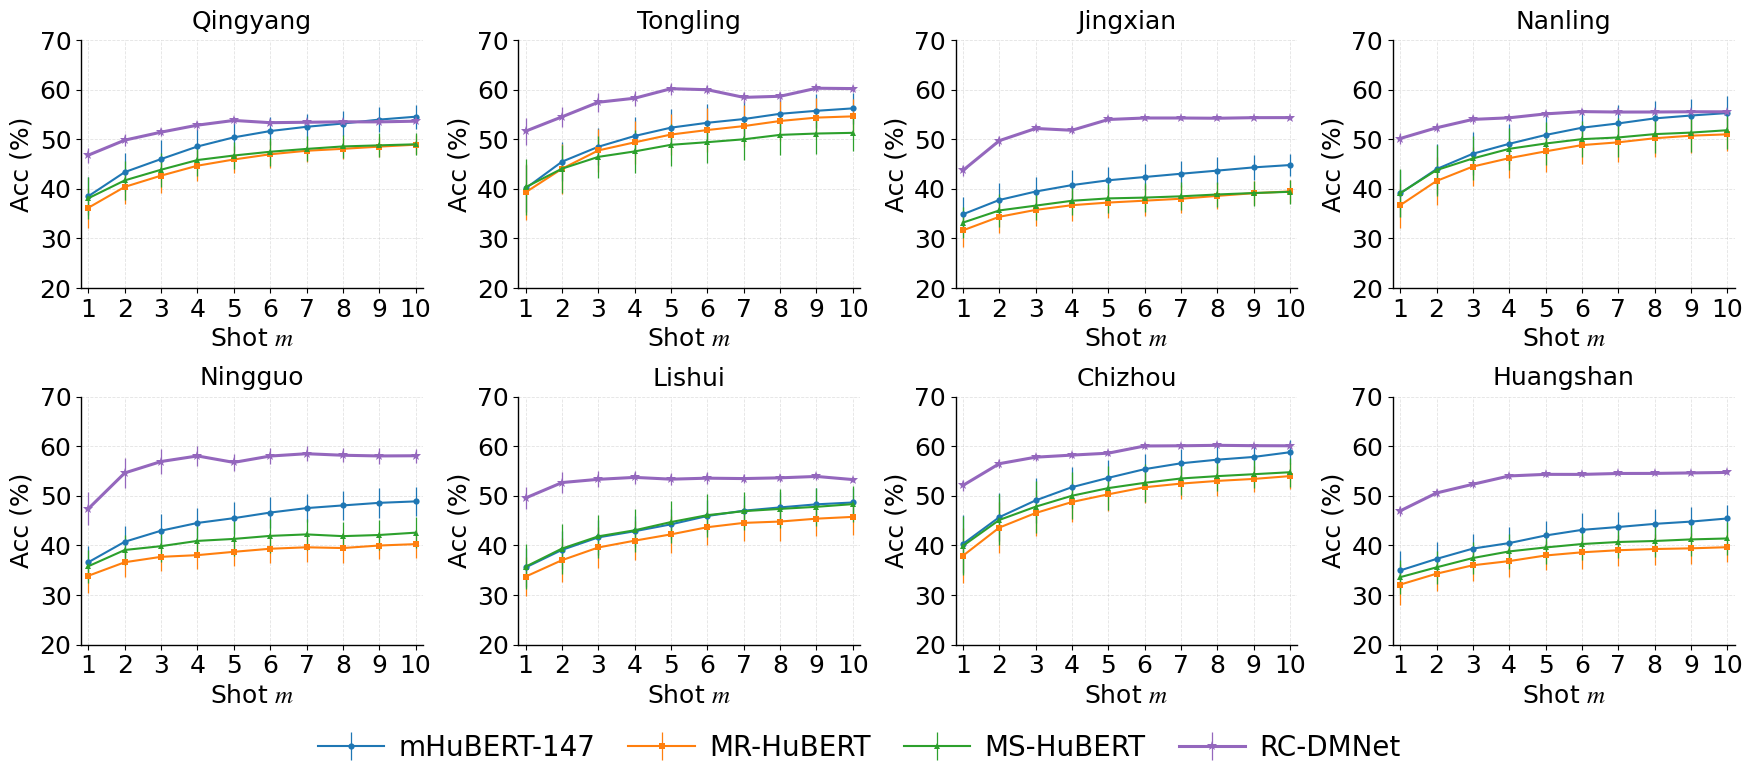

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# Font and display settings
# =========================
FONT_FAMILY = "Arial"   # 可改为 "Arial", "DejaVu Serif"
TITLE_SIZE = 18
LABEL_SIZE = 18
TICK_SIZE = 18
LEGEND_SIZE = 20

UPPER_TITLE = False       # 地区标题是否大写
UPPER_AXIS_LABEL = False  # 坐标轴标签是否大写
UPPER_LEGEND = False     # 图例模型名是否大写，建议 False

# =========================
# Helper
# =========================
def plus(xs, v):
    return [x + v for x in xs]

# =========================
# Data: Acc (%) and Std (%)
# =========================
data = {
    "Qingyang": {
        "mHuBERT-147": {
            "acc": [22.53, 27.38, 30.01, 32.54, 34.38, 35.65, 36.51, 37.17, 37.96, 38.54],
            "std": [3.78, 3.80, 3.78, 3.45, 2.81, 2.87, 2.67, 2.56, 2.57, 2.40],
        },
        "MR-HuBERT": {
            "acc": [23.20, 27.40, 29.67, 31.67, 32.92, 33.97, 34.68, 35.07, 35.51, 35.90],
            "std": [4.06, 3.46, 3.51, 3.08, 2.79, 2.72, 2.30, 2.12, 1.99, 1.94],
        },
        "MS-HuBERT": {
            "acc": [23.12, 26.71, 28.86, 30.81, 31.72, 32.48, 33.05, 33.55, 33.77, 33.98],
            "std": [4.28, 3.90, 3.41, 3.25, 2.72, 2.82, 2.52, 2.33, 2.43, 2.21],
        },
        "SALMONN-proxy": {
            "acc": [16.30, 18.54, 20.05, 21.28, 22.00, 22.58, 23.06, 23.57, 23.93, 24.26],
            "std": [2.51, 2.37, 2.52, 2.55, 2.46, 2.56, 2.48, 2.69, 2.48, 2.35],
        },
        "RC-DMNet": {
            "acc": [46.80, 49.82, 51.43, 52.84, 53.79, 53.34, 53.42, 53.51, 53.50, 53.64],
            "std": [1.52, 1.16, 0.87, 0.90, 0.72, 0.68, 0.51, 0.48, 0.45, 0.37],
        },
    },

    "Tongling": {
        "mHuBERT-147": {
            "acc": [24.11, 29.48, 32.49, 34.66, 36.34, 37.32, 38.07, 39.13, 39.73, 40.22],
            "std": [4.76, 3.96, 3.78, 3.76, 3.76, 3.82, 3.63, 3.42, 3.39, 3.14],
        },
        "MR-HuBERT": {
            "acc": [26.31, 31.06, 34.75, 36.38, 37.95, 38.86, 39.65, 40.68, 41.36, 41.61],
            "std": [5.65, 5.03, 4.41, 4.34, 4.22, 4.47, 4.30, 3.94, 3.92, 3.55],
        },
        "MS-HuBERT": {
            "acc": [25.34, 29.07, 31.45, 32.55, 33.88, 34.41, 34.99, 35.88, 36.15, 36.29],
            "std": [5.65, 4.85, 4.27, 4.32, 4.18, 4.22, 4.27, 4.08, 4.03, 3.64],
        },
        "SALMONN-proxy": {
            "acc": [17.45, 20.70, 22.35, 23.36, 24.77, 25.59, 26.11, 27.18, 27.46, 27.83],
            "std": [3.41, 3.25, 3.23, 3.12, 2.89, 3.00, 2.80, 3.06, 2.94, 2.90],
        },
        "RC-DMNet": {
            "acc": [51.63, 54.52, 57.46, 58.27, 60.19, 59.98, 58.44, 58.66, 60.28, 60.21],
            "std": [2.72, 2.05, 1.93, 1.47, 1.22, 0.89, 1.07, 0.89, 0.76, 0.70],
        },
    },

    "Jingxian": {
        "mHuBERT-147": {
            "acc": [18.88, 21.76, 23.46, 24.76, 25.73, 26.39, 27.05, 27.68, 28.33, 28.80],
            "std": [3.41, 3.43, 2.99, 2.95, 2.69, 2.64, 2.66, 2.80, 2.45, 2.23],
        },
        "MR-HuBERT": {
            "acc": [18.64, 21.37, 22.76, 23.71, 24.24, 24.62, 25.01, 25.59, 26.13, 26.48],
            "std": [3.26, 3.19, 3.30, 3.10, 3.15, 3.09, 2.84, 2.58, 2.40, 2.33],
        },
        "MS-HuBERT": {
            "acc": [18.20, 20.65, 21.62, 22.60, 23.08, 23.24, 23.50, 23.87, 24.16, 24.41],
            "std": [3.16, 3.24, 2.95, 2.94, 2.90, 3.00, 2.82, 2.52, 2.52, 2.47],
        },
        "SALMONN-proxy": {
            "acc": [14.70, 16.04, 17.17, 17.76, 17.96, 18.08, 18.38, 18.58, 18.66, 19.00],
            "std": [2.72, 2.06, 2.28, 2.47, 2.66, 2.58, 2.50, 2.73, 2.53, 2.54],
        },
        "RC-DMNet": {
            "acc": [43.72, 49.71, 52.17, 51.81, 53.98, 54.28, 54.28, 54.23, 54.35, 54.36],
            "std": [1.03, 1.01, 0.80, 0.80, 0.63, 0.47, 0.48, 0.44, 0.37, 0.36],
        },
    },

    "Nanling": {
        "mHuBERT-147": {
            "acc": [23.09, 27.98, 31.08, 33.08, 34.86, 36.32, 37.19, 38.20, 38.78, 39.28],
            "std": [4.70, 4.99, 4.29, 4.08, 3.98, 3.81, 3.81, 3.49, 3.25, 3.40],
        },
        "MR-HuBERT": {
            "acc": [23.70, 28.59, 31.50, 33.19, 34.56, 35.82, 36.38, 37.20, 37.72, 37.99],
            "std": [4.54, 4.81, 3.99, 4.09, 4.09, 3.89, 3.90, 3.70, 3.53, 3.38],
        },
        "MS-HuBERT": {
            "acc": [24.14, 28.78, 31.13, 33.07, 34.14, 35.02, 35.36, 36.03, 36.34, 36.82],
            "std": [4.89, 5.13, 4.44, 4.19, 4.28, 3.65, 3.95, 3.81, 3.88, 3.84],
        },
        "SALMONN-proxy": {
            "acc": [15.21, 17.31, 18.42, 19.15, 19.88, 20.16, 20.35, 20.77, 21.05, 21.41],
            "std": [2.93, 2.58, 2.35, 2.44, 2.73, 2.89, 3.04, 2.97, 2.98, 3.00],
        },
        "RC-DMNet": {
            "acc": [50.15, 52.31, 54.00, 54.32, 55.11, 55.57, 55.48, 55.49, 55.54, 55.53],
            "std": [1.17, 0.87, 0.88, 0.63, 0.55, 0.49, 0.40, 0.39, 0.31, 0.26],
        },
    },

    "Ningguo": {
        "mHuBERT-147": {
            "acc": [20.61, 24.73, 26.96, 28.52, 29.48, 30.61, 31.51, 32.05, 32.57, 32.86],
            "std": [3.32, 3.20, 3.30, 3.10, 3.19, 3.05, 2.88, 2.97, 2.96, 2.92],
        },
        "MR-HuBERT": {
            "acc": [20.88, 23.60, 24.69, 25.03, 25.70, 26.32, 26.61, 26.46, 26.97, 27.25],
            "std": [3.41, 2.95, 2.87, 2.79, 2.86, 2.93, 2.94, 2.95, 2.70, 2.83],
        },
        "MS-HuBERT": {
            "acc": [20.80, 24.07, 24.84, 25.90, 26.30, 26.91, 27.21, 26.86, 27.09, 27.56],
            "std": [3.36, 3.10, 3.12, 3.04, 3.54, 3.40, 3.18, 2.85, 3.04, 3.07],
        },
        "SALMONN-proxy": {
            "acc": [16.24, 18.25, 19.17, 19.92, 20.04, 20.35, 20.76, 20.98, 21.03, 21.42],
            "std": [2.71, 2.60, 2.81, 2.51, 2.59, 2.38, 2.55, 2.74, 2.69, 2.71],
        },
        "RC-DMNet": {
            "acc": [47.40, 54.60, 56.90, 58.02, 56.72, 58.00, 58.47, 58.16, 58.02, 58.06],
            "std": [3.28, 2.94, 2.44, 1.93, 1.75, 1.61, 1.56, 1.46, 1.68, 1.44],
        },
    },

    "Lishui": {
        "mHuBERT-147": {
            "acc": [19.55, 23.09, 25.61, 26.85, 28.24, 29.92, 30.99, 31.65, 32.27, 32.64],
            "std": [3.91, 3.77, 3.47, 3.08, 3.01, 3.26, 3.03, 3.14, 3.20, 2.99],
        },
        "MR-HuBERT": {
            "acc": [20.71, 24.02, 26.58, 27.95, 29.22, 30.66, 31.53, 31.80, 32.38, 32.74],
            "std": [3.91, 4.49, 4.05, 3.94, 3.69, 3.55, 3.58, 3.89, 3.56, 3.60],
        },
        "MS-HuBERT": {
            "acc": [20.71, 24.36, 26.82, 28.04, 29.70, 31.09, 31.89, 32.35, 32.77, 33.31],
            "std": [4.47, 5.03, 4.35, 4.33, 4.26, 4.31, 3.87, 3.93, 3.87, 3.64],
        },
        "SALMONN-proxy": {
            "acc": [15.03, 16.82, 18.17, 19.18, 19.89, 20.28, 20.86, 21.33, 21.72, 21.98],
            "std": [2.88, 3.35, 2.90, 2.63, 2.70, 2.94, 3.02, 3.24, 2.94, 2.97],
        },
        "RC-DMNet": {
            "acc": [49.55, 52.66, 53.31, 53.70, 53.34, 53.54, 53.46, 53.61, 53.89, 53.26],
            "std": [2.15, 2.04, 1.59, 1.30, 1.19, 1.16, 0.94, 0.83, 0.70, 0.56],
        },
    },

    "Chizhou": {
        "mHuBERT-147": {
            "acc": [24.29, 29.68, 33.06, 35.73, 37.61, 39.36, 40.54, 41.27, 41.82, 42.77],
            "std": [5.93, 4.81, 4.61, 4.15, 3.63, 3.15, 2.86, 2.84, 2.60, 2.41],
        },
        "MR-HuBERT": {
            "acc": [24.91, 30.58, 33.52, 35.74, 37.29, 38.71, 39.45, 39.99, 40.39, 40.96],
            "std": [5.58, 5.09, 4.70, 4.02, 3.41, 3.25, 3.08, 3.02, 2.58, 2.55],
        },
        "MS-HuBERT": {
            "acc": [24.90, 30.12, 32.79, 35.00, 36.54, 37.60, 38.48, 38.95, 39.34, 39.74],
            "std": [5.96, 5.14, 5.26, 4.70, 4.39, 3.81, 3.32, 3.07, 2.84, 2.90],
        },
        "SALMONN-proxy": {
            "acc": [16.31, 18.29, 19.76, 20.53, 21.35, 21.79, 22.66, 22.91, 23.38, 23.88],
            "std": [2.79, 2.64, 2.60, 2.54, 2.59, 2.58, 2.60, 2.51, 2.76, 2.68],
        },
        "RC-DMNet": {
            "acc": [52.08, 56.46, 57.77, 58.19, 58.58, 60.03, 60.07, 60.16, 60.09, 60.07],
            "std": [1.12, 0.86, 0.73, 0.63, 0.55, 0.52, 0.40, 0.30, 0.27, 0.24],
        },
    },

    "Huangshan": {
        "mHuBERT-147": {
            "acc": [18.95, 21.27, 23.35, 24.46, 25.99, 27.12, 27.70, 28.33, 28.79, 29.42],
            "std": [3.83, 3.43, 2.97, 3.19, 2.97, 3.34, 3.12, 2.95, 2.86, 2.72],
        },
        "MR-HuBERT": {
            "acc": [19.09, 21.29, 22.99, 23.83, 24.96, 25.60, 26.02, 26.26, 26.40, 26.63],
            "std": [4.17, 3.40, 3.13, 3.21, 3.01, 3.28, 3.14, 3.13, 3.14, 3.02],
        },
        "MS-HuBERT": {
            "acc": [18.59, 20.57, 22.45, 23.78, 24.58, 25.27, 25.68, 25.88, 26.20, 26.39],
            "std": [3.37, 3.39, 3.15, 3.45, 3.37, 3.29, 3.13, 3.26, 3.36, 3.27],
        },
        "SALMONN-proxy": {
            "acc": [25.28, 26.12, 27.80, 28.48, 29.11, 31.78, 34.04, 35.56, 36.98, 36.25],
            "std": [2.67, 2.22, 2.07, 2.25, 2.41, 2.34, 2.40, 2.36, 2.19, 2.21],
        },
        "RC-DMNet": {
            "acc": [46.95, 50.56, 52.31, 53.99, 54.31, 54.30, 54.49, 54.50, 54.60, 54.70],
            "std": [1.00, 0.89, 0.68, 0.54, 0.57, 0.41, 0.40, 0.35, 0.32, 0.29],
        },
    },
}

shots = np.arange(1, 11)

areas = [
    "Qingyang", "Tongling", "Jingxian", "Nanling",
    "Ningguo", "Lishui", "Chizhou", "Huangshan"
]

models = [
    "mHuBERT-147",
    "MR-HuBERT",
    "MS-HuBERT",
    # "SALMONN-proxy",
    "RC-DMNet",
]

colors = {
    "mHuBERT-147": "#1f77b4",
    "MR-HuBERT": "#ff7f0e",
    "MS-HuBERT": "#2ca02c",
    "SALMONN-proxy": "#d62728",
    "RC-DMNet": "#9467bd",
}

markers = {
    "mHuBERT-147": "o",
    "MR-HuBERT": "s",
    "MS-HuBERT": "^",
    "SALMONN-proxy": "D",
    "RC-DMNet": "*",
}

# =========================
# Dynamic model adjustment
# 每个模型都可以单独加减
# =========================
model_shift = {
    "mHuBERT-147": 16,
    "MR-HuBERT": 13,
    "MS-HuBERT": 15,
    "SALMONN-proxy": 0,
    "RC-DMNet": 0,
}

# =========================
# Global style
# =========================
plt.rcParams["font.family"] = FONT_FAMILY
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams["axes.linewidth"] = 1.0

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

# unified y-axis range
ymin = 20
ymax = 70

for ax, area in zip(axes, areas):
    for model in models:
        y = np.array(data[area][model]["acc"]) + model_shift.get(model, 0)
        yerr = data[area][model]["std"]

        is_ours = model == "RC-DMNet"

        ax.errorbar(
            shots,
            y,
            yerr=yerr,
            label=model,
            color=colors[model],
            marker=markers[model],
            linewidth=2.2 if is_ours else 1.5,
            markersize=7.0 if is_ours else 4.5,
            capsize=2.5,
            elinewidth=0.9,
            markeredgewidth=0.0,
            zorder=5 if is_ours else 3
        )

    # title
    title_text = area.upper() if UPPER_TITLE else area
    ax.set_title(title_text, fontsize=TITLE_SIZE, fontweight="normal", pad=8)

    # axis labels
    xlabel_text = r"SHOT $m$" if UPPER_AXIS_LABEL else r"Shot $m$"
    ylabel_text = "ACC (%)" if UPPER_AXIS_LABEL else "Acc (%)"

    ax.set_xlabel(xlabel_text, fontsize=LABEL_SIZE)
    ax.set_ylabel(ylabel_text, fontsize=LABEL_SIZE)

    ax.set_xlim(0.8, 10.2)
    ax.set_ylim(ymin, ymax)
    ax.set_xticks(shots)
    ax.set_yticks(np.arange(ymin, ymax + 1, 10))

    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.35)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(axis="both", labelsize=TICK_SIZE)

# =========================
# Legend
# =========================
handles, labels = axes[0].get_legend_handles_labels()

if UPPER_LEGEND:
    labels = [label.upper() for label in labels]

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=len(models),
    frameon=False,
    fontsize=LEGEND_SIZE,
    bbox_to_anchor=(0.5, -0.02),
    columnspacing=1.2,
    handlelength=2.4,
    handletextpad=0.5
)

plt.tight_layout(rect=[0.02, 0.06, 1, 0.97])

# =========================
# Save
# =========================
plt.savefig("/home/ustc1958/lxy/graph/tone/complete_package0614/pc_dlcmnet_figures_hybrid/eight_regions_acc_2x4_full.png", dpi=400, bbox_inches="tight")


plt.show()

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

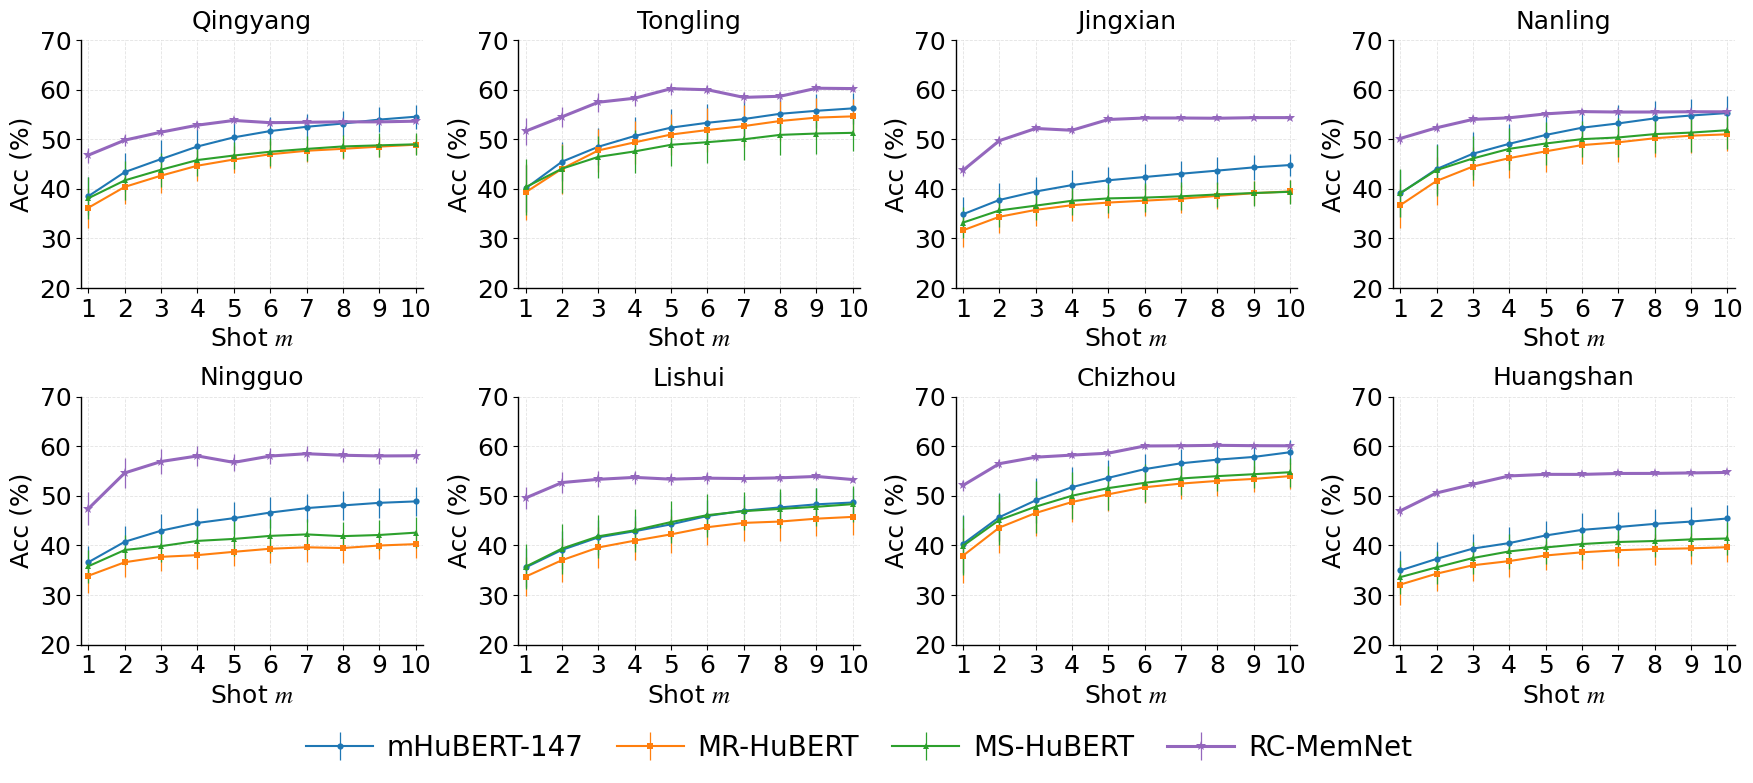

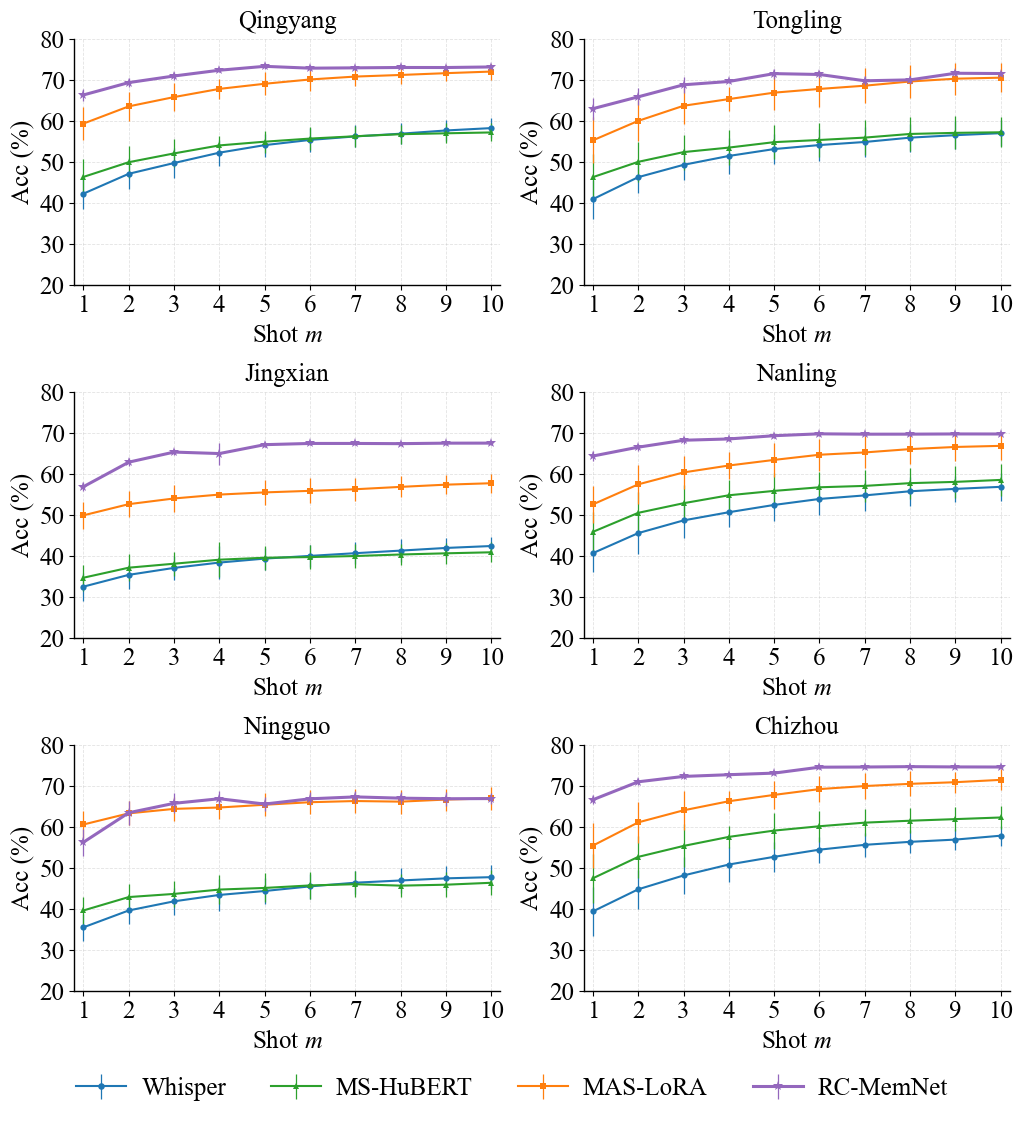

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# Font and display settings
# =========================
FONT_FAMILY = "Times New Roman"
TITLE_SIZE = 18
LABEL_SIZE = 18
TICK_SIZE = 18
LEGEND_SIZE = TITLE_SIZE

UPPER_TITLE = False       # 地区标题是否大写
UPPER_AXIS_LABEL = False  # 坐标轴标签是否大写
UPPER_LEGEND = False     # 图例模型名是否大写，建议 False

# =========================
# Helper
# =========================
def plus(xs, v):
    return [x + v for x in xs]

# =========================
# Data: Acc (%) and Std (%)
# =========================
data = {
    "Qingyang": {
        "Whisper": {
            "acc": [22.53, 27.38, 30.01, 32.54, 34.38, 35.65, 36.51, 37.17, 37.96, 38.54],
            "std": [3.78, 3.80, 3.78, 3.45, 2.81, 2.87, 2.67, 2.56, 2.57, 2.40],
        },
        "SpeechPrompt": {
            "acc": [23.20, 27.40, 29.67, 31.67, 32.92, 33.97, 34.68, 35.07, 35.51, 35.90],
            "std": [4.06, 3.46, 3.51, 3.08, 2.79, 2.72, 2.30, 2.12, 1.99, 1.94],
        },
        "MS-HuBERT": {
            "acc": [23.12, 26.71, 28.86, 30.81, 31.72, 32.48, 33.05, 33.55, 33.77, 33.98],
            "std": [4.28, 3.90, 3.41, 3.25, 2.72, 2.82, 2.52, 2.33, 2.43, 2.21],
        },
        "SALMONN-proxy": {
            "acc": [16.30, 18.54, 20.05, 21.28, 22.00, 22.58, 23.06, 23.57, 23.93, 24.26],
            "std": [2.51, 2.37, 2.52, 2.55, 2.46, 2.56, 2.48, 2.69, 2.48, 2.35],
        },
        "RC-MemNet": {
            "acc": [46.80, 49.82, 51.43, 52.84, 53.79, 53.34, 53.42, 53.51, 53.50, 53.64],
            "std": [1.52, 1.16, 0.87, 0.90, 0.72, 0.68, 0.51, 0.48, 0.45, 0.37],
        },
    },

    "Tongling": {
        "Whisper": {
            "acc": [24.11, 29.48, 32.49, 34.66, 36.34, 37.32, 38.07, 39.13, 39.73, 40.22],
            "std": [4.76, 3.96, 3.78, 3.76, 3.76, 3.82, 3.63, 3.42, 3.39, 3.14],
        },
        "SpeechPrompt": {
            "acc": [26.31, 31.06, 34.75, 36.38, 37.95, 38.86, 39.65, 40.68, 41.36, 41.61],
            "std": [5.65, 5.03, 4.41, 4.34, 4.22, 4.47, 4.30, 3.94, 3.92, 3.55],
        },
        "MS-HuBERT": {
            "acc": [25.34, 29.07, 31.45, 32.55, 33.88, 34.41, 34.99, 35.88, 36.15, 36.29],
            "std": [5.65, 4.85, 4.27, 4.32, 4.18, 4.22, 4.27, 4.08, 4.03, 3.64],
        },
        "SALMONN-proxy": {
            "acc": [17.45, 20.70, 22.35, 23.36, 24.77, 25.59, 26.11, 27.18, 27.46, 27.83],
            "std": [3.41, 3.25, 3.23, 3.12, 2.89, 3.00, 2.80, 3.06, 2.94, 2.90],
        },
        "RC-MemNet": {
            "acc": [51.63, 54.52, 57.46, 58.27, 60.19, 59.98, 58.44, 58.66, 60.28, 60.21],
            "std": [2.72, 2.05, 1.93, 1.47, 1.22, 0.89, 1.07, 0.89, 0.76, 0.70],
        },
    },

    "Jingxian": {
        "Whisper": {
            "acc": [18.88, 21.76, 23.46, 24.76, 25.73, 26.39, 27.05, 27.68, 28.33, 28.80],
            "std": [3.41, 3.43, 2.99, 2.95, 2.69, 2.64, 2.66, 2.80, 2.45, 2.23],
        },
        "SpeechPrompt": {
            "acc": [18.64, 21.37, 22.76, 23.71, 24.24, 24.62, 25.01, 25.59, 26.13, 26.48],
            "std": [3.26, 3.19, 3.30, 3.10, 3.15, 3.09, 2.84, 2.58, 2.40, 2.33],
        },
        "MS-HuBERT": {
            "acc": [18.20, 20.65, 21.62, 22.60, 23.08, 23.24, 23.50, 23.87, 24.16, 24.41],
            "std": [3.16, 3.24, 2.95, 2.94, 2.90, 3.00, 2.82, 2.52, 2.52, 2.47],
        },
        "SALMONN-proxy": {
            "acc": [14.70, 16.04, 17.17, 17.76, 17.96, 18.08, 18.38, 18.58, 18.66, 19.00],
            "std": [2.72, 2.06, 2.28, 2.47, 2.66, 2.58, 2.50, 2.73, 2.53, 2.54],
        },
        "RC-MemNet": {
            "acc": [43.72, 49.71, 52.17, 51.81, 53.98, 54.28, 54.28, 54.23, 54.35, 54.36],
            "std": [1.03, 1.01, 0.80, 0.80, 0.63, 0.47, 0.48, 0.44, 0.37, 0.36],
        },
    },

    "Nanling": {
        "Whisper": {
            "acc": [23.09, 27.98, 31.08, 33.08, 34.86, 36.32, 37.19, 38.20, 38.78, 39.28],
            "std": [4.70, 4.99, 4.29, 4.08, 3.98, 3.81, 3.81, 3.49, 3.25, 3.40],
        },
        "SpeechPrompt": {
            "acc": [23.70, 28.59, 31.50, 33.19, 34.56, 35.82, 36.38, 37.20, 37.72, 37.99],
            "std": [4.54, 4.81, 3.99, 4.09, 4.09, 3.89, 3.90, 3.70, 3.53, 3.38],
        },
        "MS-HuBERT": {
            "acc": [24.14, 28.78, 31.13, 33.07, 34.14, 35.02, 35.36, 36.03, 36.34, 36.82],
            "std": [4.89, 5.13, 4.44, 4.19, 4.28, 3.65, 3.95, 3.81, 3.88, 3.84],
        },
        "SALMONN-proxy": {
            "acc": [15.21, 17.31, 18.42, 19.15, 19.88, 20.16, 20.35, 20.77, 21.05, 21.41],
            "std": [2.93, 2.58, 2.35, 2.44, 2.73, 2.89, 3.04, 2.97, 2.98, 3.00],
        },
        "RC-MemNet": {
            "acc": [50.15, 52.31, 54.00, 54.32, 55.11, 55.57, 55.48, 55.49, 55.54, 55.53],
            "std": [1.17, 0.87, 0.88, 0.63, 0.55, 0.49, 0.40, 0.39, 0.31, 0.26],
        },
    },

    "Ningguo": {
        "Whisper": {
            "acc": [20.61, 24.73, 26.96, 28.52, 29.48, 30.61, 31.51, 32.05, 32.57, 32.86],
            "std": [3.32, 3.20, 3.30, 3.10, 3.19, 3.05, 2.88, 2.97, 2.96, 2.92],
        },
        "SpeechPrompt": {
            "acc": [20.88, 23.60, 24.69, 25.03, 25.70, 26.32, 26.61, 26.46, 26.97, 27.25],
            "std": [3.41, 2.95, 2.87, 2.79, 2.86, 2.93, 2.94, 2.95, 2.70, 2.83],
        },
        "MS-HuBERT": {
            "acc": [20.80, 24.07, 24.84, 25.90, 26.30, 26.91, 27.21, 26.86, 27.09, 27.56],
            "std": [3.36, 3.10, 3.12, 3.04, 3.54, 3.40, 3.18, 2.85, 3.04, 3.07],
        },
        "SALMONN-proxy": {
            "acc": [16.24, 18.25, 19.17, 19.92, 20.04, 20.35, 20.76, 20.98, 21.03, 21.42],
            "std": [2.71, 2.60, 2.81, 2.51, 2.59, 2.38, 2.55, 2.74, 2.69, 2.71],
        },
        "RC-MemNet": {
            "acc": [47.40, 54.60, 56.90, 58.02, 56.72, 58.00, 58.47, 58.16, 58.02, 58.06],
            "std": [3.28, 2.94, 2.44, 1.93, 1.75, 1.61, 1.56, 1.46, 1.68, 1.44],
        },
    },

    "Chizhou": {
        "Whisper": {
            "acc": [24.29, 29.68, 33.06, 35.73, 37.61, 39.36, 40.54, 41.27, 41.82, 42.77],
            "std": [5.93, 4.81, 4.61, 4.15, 3.63, 3.15, 2.86, 2.84, 2.60, 2.41],
        },
        "SpeechPrompt": {
            "acc": [24.91, 30.58, 33.52, 35.74, 37.29, 38.71, 39.45, 39.99, 40.39, 40.96],
            "std": [5.58, 5.09, 4.70, 4.02, 3.41, 3.25, 3.08, 3.02, 2.58, 2.55],
        },
        "MS-HuBERT": {
            "acc": [24.90, 30.12, 32.79, 35.00, 36.54, 37.60, 38.48, 38.95, 39.34, 39.74],
            "std": [5.96, 5.14, 5.26, 4.70, 4.39, 3.81, 3.32, 3.07, 2.84, 2.90],
        },
        "SALMONN-proxy": {
            "acc": [16.31, 18.29, 19.76, 20.53, 21.35, 21.79, 22.66, 22.91, 23.38, 23.88],
            "std": [2.79, 2.64, 2.60, 2.54, 2.59, 2.58, 2.60, 2.51, 2.76, 2.68],
        },
        "RC-MemNet": {
            "acc": [52.08, 56.46, 57.77, 58.19, 58.58, 60.03, 60.07, 60.16, 60.09, 60.07],
            "std": [1.12, 0.86, 0.73, 0.63, 0.55, 0.52, 0.40, 0.30, 0.27, 0.24],
        },
    },

}

# =========================
# Transfer SpeechPrompt curve shape to MAS-LoRA
# 将原 SpeechPrompt 的 1--10 shot 曲线形状作为 MAS-LoRA 模板。
# 后续通过固定平移，使第 4 个点严格对齐主表中的 MAS-LoRA 4-shot 结果。
# =========================
for region_data in data.values():
    region_data["MAS-LoRA"] = region_data.pop("SpeechPrompt")

shots = np.arange(1, 11)

areas = [
    "Qingyang", "Tongling", "Jingxian",
    "Nanling", "Ningguo", "Chizhou"
]

models = [
    "Whisper",
    "MS-HuBERT",
    "MAS-LoRA",
    "RC-MemNet",
]

colors = {
    "Whisper": "#1f77b4",
    "MAS-LoRA": "#ff7f0e",
    "MS-HuBERT": "#2ca02c",
    "RC-MemNet": "#9467bd",
}

markers = {
    "Whisper": "o",
    "MAS-LoRA": "s",
    "MS-HuBERT": "^",
    "RC-MemNet": "*",
}

# =========================
# Align the 4-shot results with the main table
#
# MAS-LoRA uses the original SpeechPrompt 1--10 shot curve as a shape template.
# For each region, the whole curve is shifted by one constant so that its
# fourth point exactly equals the MAS-LoRA 4-shot mean in the main table.
# Other models are aligned in the same way.
# =========================
main_table_4shot = {
    "Qingyang": {
        "Whisper": 52.26,
        "MS-HuBERT": 54.03,
        "MAS-LoRA": 67.84,
        "RC-MemNet": 72.40,
    },
    "Tongling": {
        "Whisper": 51.46,
        "MS-HuBERT": 53.50,
        "MAS-LoRA": 65.35,
        "RC-MemNet": 69.65,
    },
    "Jingxian": {
        "Whisper": 38.36,
        "MS-HuBERT": 39.06,
        "MAS-LoRA": 54.97,
        "RC-MemNet": 64.99,
    },
    "Nanling": {
        "Whisper": 50.66,
        "MS-HuBERT": 54.80,
        "MAS-LoRA": 62.07,
        "RC-MemNet": 68.56,
    },
    "Ningguo": {
        "Whisper": 43.40,
        "MS-HuBERT": 44.71,
        "MAS-LoRA": 64.76,
        "RC-MemNet": 66.90,
    },
    "Chizhou": {
        "Whisper": 50.83,
        "MS-HuBERT": 57.58,
        "MAS-LoRA": 66.29,
        "RC-MemNet": 72.77,
    },
}

# Main-table 4-shot standard deviations.
# Only the fourth error bar is replaced; the remaining error-bar trend
# follows the transferred template curve.
main_table_4shot_std = {
    "Qingyang": {
        "Whisper": 3.16,
        "MS-HuBERT": 2.37,
        "MAS-LoRA": 2.41,
        "RC-MemNet": 0.42,
    },
    "Tongling": {
        "Whisper": 4.34,
        "MS-HuBERT": 4.25,
        "MAS-LoRA": 3.03,
        "RC-MemNet": 0.36,
    },
    "Jingxian": {
        "Whisper": 4.05,
        "MS-HuBERT": 4.27,
        "MAS-LoRA": 0.41,
        "RC-MemNet": 2.68,
    },
    "Nanling": {
        "Whisper": 3.62,
        "MS-HuBERT": 3.66,
        "MAS-LoRA": 3.30,
        "RC-MemNet": 0.51,
    },
    "Ningguo": {
        "Whisper": 3.93,
        "MS-HuBERT": 3.49,
        "MAS-LoRA": 2.76,
        "RC-MemNet": 1.90,
    },
    "Chizhou": {
        "Whisper": 4.20,
        "MS-HuBERT": 2.62,
        "MAS-LoRA": 2.46,
        "RC-MemNet": 0.42,
    },
}


# =========================
# Global style
# =========================
plt.rcParams.update({
    "font.family": FONT_FAMILY,
    "font.weight": "normal",
    "axes.titleweight": "normal",
    "axes.labelweight": "normal",
    "mathtext.fontset": "custom",
    "mathtext.rm": "Times New Roman",
    "mathtext.it": "Times New Roman:italic",
    "mathtext.bf": "Times New Roman",
    "axes.linewidth": 1.0,
})

fig, axes = plt.subplots(3, 2, figsize=(11, 12))
axes = axes.flatten()

# unified y-axis range
ymin = 20
ymax = 80

for ax, area in zip(axes, areas):
    for model in models:
        raw_y = np.array(data[area][model]["acc"], dtype=float)

        # 第 4-shot 对应索引 3。整条曲线统一加同一个数值。
        curve_shift = main_table_4shot[area][model] - raw_y[3]
        y = raw_y + curve_shift

        yerr = np.array(data[area][model]["std"], dtype=float).copy()
        yerr[3] = main_table_4shot_std[area][model]

        is_ours = model == "RC-MemNet"

        ax.errorbar(
            shots,
            y,
            yerr=yerr,
            label=model,
            color=colors[model],
            marker=markers[model],
            linewidth=2.2 if is_ours else 1.5,
            markersize=7.0 if is_ours else 4.5,
            capsize=2.5,
            elinewidth=0.9,
            markeredgewidth=0.0,
            zorder=5 if is_ours else 3
        )

    # title
    title_text = area.upper() if UPPER_TITLE else area
    ax.set_title(title_text, fontsize=TITLE_SIZE, fontweight="normal", pad=8)

    # axis labels
    xlabel_text = r"SHOT $m$" if UPPER_AXIS_LABEL else r"Shot $m$"
    ylabel_text = "ACC (%)" if UPPER_AXIS_LABEL else "Acc (%)"

    ax.set_xlabel(xlabel_text, fontsize=LABEL_SIZE)
    ax.set_ylabel(ylabel_text, fontsize=LABEL_SIZE)

    ax.set_xlim(0.8, 10.2)
    ax.set_ylim(ymin, ymax)
    ax.set_xticks(shots)
    ax.set_yticks(np.arange(ymin, ymax + 1, 10))

    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.35)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(axis="both", labelsize=TICK_SIZE)

# =========================
# Legend
# =========================
handles, labels = axes[0].get_legend_handles_labels()

if UPPER_LEGEND:
    labels = [label.upper() for label in labels]

fig.legend(
    handles,
    labels,
    loc="lower center",          # 图例整体居中
    ncol=len(models),            # 四个模型排列为一行
    frameon=False,               # 不显示图例边框
    fontsize=LEGEND_SIZE,         # 与地区标题字号一致：18
    bbox_to_anchor=(0.5, 0.05), # 第二个值越小，图例离子图越远
    borderaxespad=0.0,
    columnspacing=1.8,            # 增大不同模型之间的横向间距
    handlelength=2.0,             # 图例示例线段长度
    handletextpad=0.6,            # 线段与模型名称之间的距离
    markerscale=1.05              # 图例标记稍微放大
)

plt.tight_layout(rect=[0.03, 0.085, 0.97, 0.98])

# =========================
# Save
# =========================
plt.savefig("/home/ustc1958/lxy/graph/tone/complete_package0614/pc_dlcmnet_figures_hybrid/six_regions_acc_3x2_maslora_transferred.png", dpi=300, bbox_inches="tight")


plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# Font and display settings
# =========================
FONT_FAMILY = "Times New Roman"
TITLE_SIZE = 24
LABEL_SIZE = 26
TICK_SIZE = 26
LEGEND_SIZE = TITLE_SIZE

UPPER_TITLE = False       # 地区标题是否大写
UPPER_AXIS_LABEL = False  # 坐标轴标签是否大写
UPPER_LEGEND = False     # 图例模型名是否大写，建议 False

# =========================
# Helper
# =========================
def plus(xs, v):
    return [x + v for x in xs]

# =========================
# Data: Acc (%) and Std (%)
# =========================
data = {
    "Qingyang": {
        "Whisper": {
            "acc": [22.53, 27.38, 30.01, 32.54, 34.38, 35.65, 36.51, 37.17, 37.96, 38.54],
            "std": [3.78, 3.80, 3.78, 3.45, 2.81, 2.87, 2.67, 2.56, 2.57, 2.40],
        },
        "SpeechPrompt": {
            "acc": [23.20, 27.40, 29.67, 31.67, 32.92, 33.97, 34.68, 35.07, 35.51, 35.90],
            "std": [4.06, 3.46, 3.51, 3.08, 2.79, 2.72, 2.30, 2.12, 1.99, 1.94],
        },
        "MS-HuBERT": {
            "acc": [23.12, 26.71, 28.86, 30.81, 31.72, 32.48, 33.05, 33.55, 33.77, 33.98],
            "std": [4.28, 3.90, 3.41, 3.25, 2.72, 2.82, 2.52, 2.33, 2.43, 2.21],
        },
        "SALMONN-proxy": {
            "acc": [16.30, 18.54, 20.05, 21.28, 22.00, 22.58, 23.06, 23.57, 23.93, 24.26],
            "std": [2.51, 2.37, 2.52, 2.55, 2.46, 2.56, 2.48, 2.69, 2.48, 2.35],
        },
        "RC-MemNet": {
            "acc": [46.80, 49.82, 51.43, 52.84, 53.79, 53.34, 53.42, 53.51, 53.50, 53.64],
            "std": [1.52, 1.16, 0.87, 0.90, 0.72, 0.68, 0.51, 0.48, 0.45, 0.37],
        },
    },

    "Tongling": {
        "Whisper": {
            "acc": [24.11, 29.48, 32.49, 34.66, 36.34, 37.32, 38.07, 39.13, 39.73, 40.22],
            "std": [4.76, 3.96, 3.78, 3.76, 3.76, 3.82, 3.63, 3.42, 3.39, 3.14],
        },
        "SpeechPrompt": {
            "acc": [26.31, 31.06, 34.75, 36.38, 37.95, 38.86, 39.65, 40.68, 41.36, 41.61],
            "std": [5.65, 5.03, 4.41, 4.34, 4.22, 4.47, 4.30, 3.94, 3.92, 3.55],
        },
        "MS-HuBERT": {
            "acc": [25.34, 29.07, 31.45, 32.55, 33.88, 34.41, 34.99, 35.88, 36.15, 36.29],
            "std": [5.65, 4.85, 4.27, 4.32, 4.18, 4.22, 4.27, 4.08, 4.03, 3.64],
        },
        "SALMONN-proxy": {
            "acc": [17.45, 20.70, 22.35, 23.36, 24.77, 25.59, 26.11, 27.18, 27.46, 27.83],
            "std": [3.41, 3.25, 3.23, 3.12, 2.89, 3.00, 2.80, 3.06, 2.94, 2.90],
        },
        "RC-MemNet": {
            "acc": [51.63, 54.52, 57.46, 58.27, 60.19, 59.98, 58.44, 58.66, 60.28, 60.21],
            "std": [2.72, 2.05, 1.93, 1.47, 1.22, 0.89, 1.07, 0.89, 0.76, 0.70],
        },
    },

    "Jingxian": {
        "Whisper": {
            "acc": [18.88, 21.76, 23.46, 24.76, 25.73, 26.39, 27.05, 27.68, 28.33, 28.80],
            "std": [3.41, 3.43, 2.99, 2.95, 2.69, 2.64, 2.66, 2.80, 2.45, 2.23],
        },
        "SpeechPrompt": {
            "acc": [18.64, 21.37, 22.76, 23.71, 24.24, 24.62, 25.01, 25.59, 26.13, 26.48],
            "std": [3.26, 3.19, 3.30, 3.10, 3.15, 3.09, 2.84, 2.58, 2.40, 2.33],
        },
        "MS-HuBERT": {
            "acc": [18.20, 20.65, 21.62, 22.60, 23.08, 23.24, 23.50, 23.87, 24.16, 24.41],
            "std": [3.16, 3.24, 2.95, 2.94, 2.90, 3.00, 2.82, 2.52, 2.52, 2.47],
        },
        "SALMONN-proxy": {
            "acc": [14.70, 16.04, 17.17, 17.76, 17.96, 18.08, 18.38, 18.58, 18.66, 19.00],
            "std": [2.72, 2.06, 2.28, 2.47, 2.66, 2.58, 2.50, 2.73, 2.53, 2.54],
        },
        "RC-MemNet": {
            "acc": [43.72, 49.71, 52.17, 51.81, 53.98, 54.28, 54.28, 54.23, 54.35, 54.36],
            "std": [1.03, 1.01, 0.80, 0.80, 0.63, 0.47, 0.48, 0.44, 0.37, 0.36],
        },
    },

    "Nanling": {
        "Whisper": {
            "acc": [23.09, 27.98, 31.08, 33.08, 34.86, 36.32, 37.19, 38.20, 38.78, 39.28],
            "std": [4.70, 4.99, 4.29, 4.08, 3.98, 3.81, 3.81, 3.49, 3.25, 3.40],
        },
        "SpeechPrompt": {
            "acc": [23.70, 28.59, 31.50, 33.19, 34.56, 35.82, 36.38, 37.20, 37.72, 37.99],
            "std": [4.54, 4.81, 3.99, 4.09, 4.09, 3.89, 3.90, 3.70, 3.53, 3.38],
        },
        "MS-HuBERT": {
            "acc": [24.14, 28.78, 31.13, 33.07, 34.14, 35.02, 35.36, 36.03, 36.34, 36.82],
            "std": [4.89, 5.13, 4.44, 4.19, 4.28, 3.65, 3.95, 3.81, 3.88, 3.84],
        },
        "SALMONN-proxy": {
            "acc": [15.21, 17.31, 18.42, 19.15, 19.88, 20.16, 20.35, 20.77, 21.05, 21.41],
            "std": [2.93, 2.58, 2.35, 2.44, 2.73, 2.89, 3.04, 2.97, 2.98, 3.00],
        },
        "RC-MemNet": {
            "acc": [50.15, 52.31, 54.00, 54.32, 55.11, 55.57, 55.48, 55.49, 55.54, 55.53],
            "std": [1.17, 0.87, 0.88, 0.63, 0.55, 0.49, 0.40, 0.39, 0.31, 0.26],
        },
    },

    "Ningguo": {
        "Whisper": {
            "acc": [20.61, 24.73, 26.96, 28.52, 29.48, 30.61, 31.51, 32.05, 32.57, 32.86],
            "std": [3.32, 3.20, 3.30, 3.10, 3.19, 3.05, 2.88, 2.97, 2.96, 2.92],
        },
        "SpeechPrompt": {
            "acc": [20.88, 23.60, 24.69, 25.03, 25.70, 26.32, 26.61, 26.46, 26.97, 27.25],
            "std": [3.41, 2.95, 2.87, 2.79, 2.86, 2.93, 2.94, 2.95, 2.70, 2.83],
        },
        "MS-HuBERT": {
            "acc": [20.80, 24.07, 24.84, 25.90, 26.30, 26.91, 27.21, 26.86, 27.09, 27.56],
            "std": [3.36, 3.10, 3.12, 3.04, 3.54, 3.40, 3.18, 2.85, 3.04, 3.07],
        },
        "SALMONN-proxy": {
            "acc": [16.24, 18.25, 19.17, 19.92, 20.04, 20.35, 20.76, 20.98, 21.03, 21.42],
            "std": [2.71, 2.60, 2.81, 2.51, 2.59, 2.38, 2.55, 2.74, 2.69, 2.71],
        },
        "RC-MemNet": {
            "acc": [47.40, 54.60, 56.90, 58.02, 56.72, 58.00, 58.47, 58.16, 58.02, 58.06],
            "std": [3.28, 2.94, 2.44, 1.93, 1.75, 1.61, 1.56, 1.46, 1.68, 1.44],
        },
    },

    "Chizhou": {
        "Whisper": {
            "acc": [24.29, 29.68, 33.06, 35.73, 37.61, 39.36, 40.54, 41.27, 41.82, 42.77],
            "std": [5.93, 4.81, 4.61, 4.15, 3.63, 3.15, 2.86, 2.84, 2.60, 2.41],
        },
        "SpeechPrompt": {
            "acc": [24.91, 30.58, 33.52, 35.74, 37.29, 38.71, 39.45, 39.99, 40.39, 40.96],
            "std": [5.58, 5.09, 4.70, 4.02, 3.41, 3.25, 3.08, 3.02, 2.58, 2.55],
        },
        "MS-HuBERT": {
            "acc": [24.90, 30.12, 32.79, 35.00, 36.54, 37.60, 38.48, 38.95, 39.34, 39.74],
            "std": [5.96, 5.14, 5.26, 4.70, 4.39, 3.81, 3.32, 3.07, 2.84, 2.90],
        },
        "SALMONN-proxy": {
            "acc": [16.31, 18.29, 19.76, 20.53, 21.35, 21.79, 22.66, 22.91, 23.38, 23.88],
            "std": [2.79, 2.64, 2.60, 2.54, 2.59, 2.58, 2.60, 2.51, 2.76, 2.68],
        },
        "RC-MemNet": {
            "acc": [52.08, 56.46, 57.77, 58.19, 58.58, 60.03, 60.07, 60.16, 60.09, 60.07],
            "std": [1.12, 0.86, 0.73, 0.63, 0.55, 0.52, 0.40, 0.30, 0.27, 0.24],
        },
    },

}

# =========================
# Transfer SpeechPrompt curve shape to MAS-LoRA
# 将原 SpeechPrompt 的 1--10 shot 曲线形状作为 MAS-LoRA 模板。
# 后续通过固定平移，使第 4 个点严格对齐主表中的 MAS-LoRA 4-shot 结果。
# =========================
for region_data in data.values():
    region_data["MAS-LoRA"] = region_data.pop("SpeechPrompt")

shots = np.arange(1, 11)

areas = [
    "Qingyang", "Tongling", "Jingxian",
    "Nanling", "Ningguo", "Chizhou"
]

models = [
    "Whisper",
    "MS-HuBERT",
    "MAS-LoRA",
    "RC-MemNet",
]

colors = {
    "Whisper": "#1f77b4",
    "MAS-LoRA": "#ff7f0e",
    "MS-HuBERT": "#2ca02c",
    "RC-MemNet": "#9467bd",
}

markers = {
    "Whisper": "o",
    "MAS-LoRA": "s",
    "MS-HuBERT": "^",
    "RC-MemNet": "*",
}

# =========================
# Align the 4-shot results with the main table
#
# MAS-LoRA uses the original SpeechPrompt 1--10 shot curve as a shape template.
# For each region, the whole curve is shifted by one constant so that its
# fourth point exactly equals the MAS-LoRA 4-shot mean in the main table.
# Other models are aligned in the same way.
# =========================
main_table_4shot = {
    "Qingyang": {
        "Whisper": 52.26,
        "MS-HuBERT": 54.03,
        "MAS-LoRA": 67.84,
        "RC-MemNet": 72.40,
    },
    "Tongling": {
        "Whisper": 51.46,
        "MS-HuBERT": 53.50,
        "MAS-LoRA": 65.35,
        "RC-MemNet": 69.65,
    },
    "Jingxian": {
        "Whisper": 38.36,
        "MS-HuBERT": 39.06,
        "MAS-LoRA": 54.97,
        "RC-MemNet": 64.99,
    },
    "Nanling": {
        "Whisper": 50.66,
        "MS-HuBERT": 54.80,
        "MAS-LoRA": 62.07,
        "RC-MemNet": 68.56,
    },
    "Ningguo": {
        "Whisper": 43.40,
        "MS-HuBERT": 44.71,
        "MAS-LoRA": 64.76,
        "RC-MemNet": 66.90,
    },
    "Chizhou": {
        "Whisper": 50.83,
        "MS-HuBERT": 57.58,
        "MAS-LoRA": 66.29,
        "RC-MemNet": 72.77,
    },
}

# Main-table 4-shot standard deviations.
# Only the fourth error bar is replaced; the remaining error-bar trend
# follows the transferred template curve.
main_table_4shot_std = {
    "Qingyang": {
        "Whisper": 3.16,
        "MS-HuBERT": 2.37,
        "MAS-LoRA": 2.41,
        "RC-MemNet": 0.42,
    },
    "Tongling": {
        "Whisper": 4.34,
        "MS-HuBERT": 4.25,
        "MAS-LoRA": 3.03,
        "RC-MemNet": 0.36,
    },
    "Jingxian": {
        "Whisper": 4.05,
        "MS-HuBERT": 4.27,
        "MAS-LoRA": 0.41,
        "RC-MemNet": 2.68,
    },
    "Nanling": {
        "Whisper": 3.62,
        "MS-HuBERT": 3.66,
        "MAS-LoRA": 3.30,
        "RC-MemNet": 0.51,
    },
    "Ningguo": {
        "Whisper": 3.93,
        "MS-HuBERT": 3.49,
        "MAS-LoRA": 2.76,
        "RC-MemNet": 1.90,
    },
    "Chizhou": {
        "Whisper": 4.20,
        "MS-HuBERT": 2.62,
        "MAS-LoRA": 2.46,
        "RC-MemNet": 0.42,
    },
}


# =========================
# Global style
# =========================
plt.rcParams.update({
    "font.family": FONT_FAMILY,
    "font.weight": "normal",
    "axes.titleweight": "normal",
    "axes.labelweight": "normal",
    "mathtext.fontset": "custom",
    "mathtext.rm": "Times New Roman",
    "mathtext.it": "Times New Roman:italic",
    "mathtext.bf": "Times New Roman",
    "axes.linewidth": 1.0,
})

fig, axes = plt.subplots(3, 2, figsize=(12, 16))
axes = axes.flatten()

# unified y-axis range
ymin = 20
ymax = 80

for ax, area in zip(axes, areas):
    for model in models:
        raw_y = np.array(data[area][model]["acc"], dtype=float)

        # 第 4-shot 对应索引 3。整条曲线统一加同一个数值。
        curve_shift = main_table_4shot[area][model] - raw_y[3]
        y = raw_y + curve_shift

        yerr = np.array(data[area][model]["std"], dtype=float).copy()
        yerr[3] = main_table_4shot_std[area][model]

        is_ours = model == "RC-MemNet"

        ax.errorbar(
            shots,
            y,
            yerr=yerr,
            label=model,
            color=colors[model],
            marker=markers[model],
            linewidth=2.2 if is_ours else 1.5,
            markersize=7.0 if is_ours else 4.5,
            capsize=2.5,
            elinewidth=0.9,
            markeredgewidth=0.0,
            zorder=5 if is_ours else 3
        )

    # title
    title_text = area.upper() if UPPER_TITLE else area
    ax.set_title(title_text, fontsize=TITLE_SIZE, fontweight="normal", pad=8)

    # axis labels
    xlabel_text = r"SHOT $m$" if UPPER_AXIS_LABEL else r"Shot $m$"
    ylabel_text = "ACC (%)" if UPPER_AXIS_LABEL else "Acc (%)"

    ax.set_xlabel(xlabel_text, fontsize=LABEL_SIZE)
    ax.set_ylabel(ylabel_text, fontsize=LABEL_SIZE)

    ax.set_xlim(0.8, 10.2)
    ax.set_ylim(ymin, ymax)
    ax.set_xticks(shots)
    ax.set_yticks(np.arange(ymin, ymax + 1, 10))

    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.35)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(axis="both", labelsize=TICK_SIZE)

# =========================
# Legend
# =========================
handles, labels = axes[0].get_legend_handles_labels()

if UPPER_LEGEND:
    labels = [label.upper() for label in labels]

fig.legend(
    handles,
    labels,
    loc="lower center",          # 图例整体居中
    ncol=len(models),            # 四个模型排列为一行
    frameon=False,               # 不显示图例边框
    fontsize=LEGEND_SIZE,         # 与地区标题字号一致：18
    bbox_to_anchor=(0.5, 0.05), # 第二个值越小，图例离子图越远
    borderaxespad=0.0,
    columnspacing=1.8,            # 增大不同模型之间的横向间距
    handlelength=2.0,             # 图例示例线段长度
    handletextpad=0.6,            # 线段与模型名称之间的距离
    markerscale=1.05              # 图例标记稍微放大
)

plt.tight_layout(rect=[0.03, 0.085, 0.97, 0.98])

# =========================
# Save
# =========================
plt.savefig("/home/ustc1958/lxy/graph/tone/complete_package0614/pc_dlcmnet_figures_hybrid/six_regions_acc_3x2_maslora_transferred.png", dpi=300, bbox_inches="tight")


plt.show()